In [1]:
%run -i ./01_definitions.ipynb
%matplotlib widget

In [2]:
def _plot_surface(g, x_lab='x', y_lab='y', z_lab='posterior', ax_lo=-5, ax_hi=5, ay_lo=-5, ay_hi=5, n=60):
  xs = np.linspace(ax_lo, ax_hi, n + 1)
  ys = np.linspace(ay_lo, ay_hi, n + 1)
  Z = [[g(x, y) for x in xs] for y in ys]
  fig = go.Figure(data=[go.Surface(x=xs, y=ys, z=Z)])
  fig.update_layout(scene=dict(xaxis_title=x_lab, yaxis_title=y_lab, zaxis_title=z_lab), margin=dict(l=0, r=0, t=30, b=0),)
  fig.show()
  fig.show(renderer="png")
  return fig

We can always factor a joint probability density into a conditional and an unconditional factor:

$$p(\mathbf{x}, \mathbf{y}) = p(\mathbf{x}|\mathbf{y})\,p(\mathbf{y}) = p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x}). \tag{2.8}$$

This one statement has important ramifications.

First, the process of integrating out one or more variables from a joint density, $p(\mathbf{x}, \mathbf{y})$, is called *marginalization*. For example, integrating the joint density over $\mathbf{x}$ reveals

$$\int p(\mathbf{x}, \mathbf{y})\,d\mathbf{x} = \int p(\mathbf{x}|\mathbf{y})\,p(\mathbf{y})\,d\mathbf{x} = \underbrace{\int p(\mathbf{x}|\mathbf{y})\,d\mathbf{x}}_{1}\, p(\mathbf{y}) = p(\mathbf{y}). \tag{2.9}$$

The result, $p(\mathbf{y})$, is the *marginal* of the joint density for $\mathbf{y}$. Clearly then, the marginal for $\mathbf{x}$ is $p(\mathbf{x}) = \int p(\mathbf{x}, \mathbf{y})\,d\mathbf{y}$.

In [3]:
# (p(x, y), x) -> p(x) / (p(x, y), y) -> p(y)
def _marginalize(pxy=None, keep=''):
  if keep == 'y':
    def py(y):
      def pxgy(x):
        return pxy(x, y)
      return _integrate(pxgy)
    return py
  elif keep == 'x':
    def px(x):
      def pygx(y):
        return pxy(x, y)
      return _integrate(pygx)
    return px

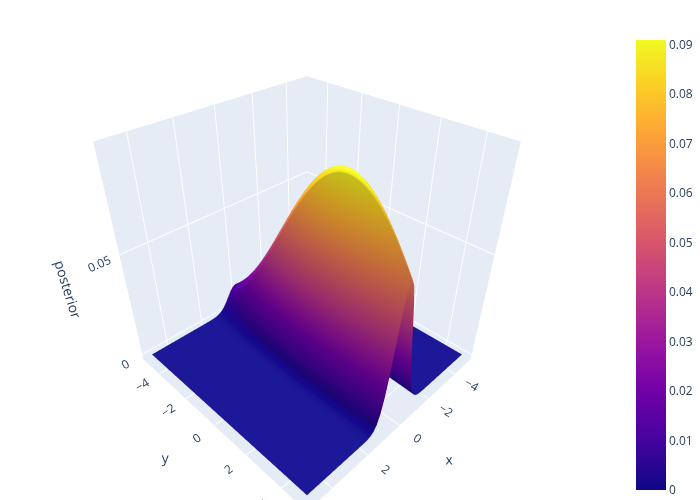

In [4]:
if __name__ == '__main__' and '__file__' not in globals():
  def make_pxy():
    def pxy(x, y):
      px = _gaussian(0.0, 0.5)
      py = _gaussian(2.0, 3.5)
      return px(x) * py(y)
    return pxy
  pxy = make_pxy()
  _plot_surface(pxy)

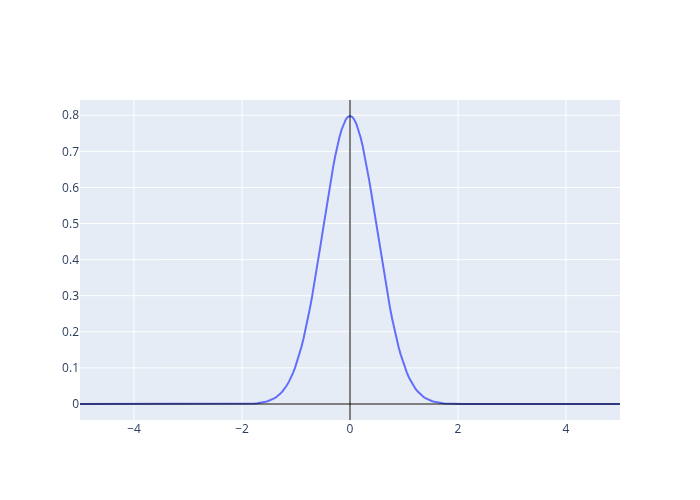

In [5]:
if __name__ == '__main__' and '__file__' not in globals():
  px = _marginalize(pxy=pxy, keep='x')
  _plot_function(px, (-5, 5))

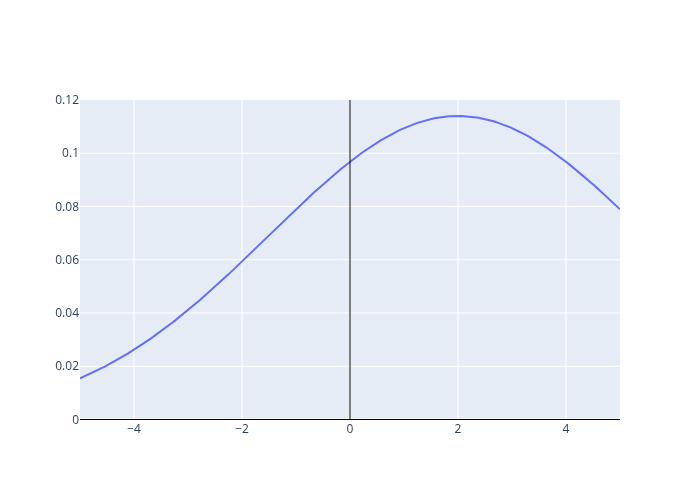

In [6]:
if __name__ == '__main__' and '__file__' not in globals():
  py = _marginalize(pxy=pxy, keep='y')
  _plot_function(py, (-5, 5))

Second, rearranging (2.8) gives *Bayes' rule* (a.k.a., Bayes' theorem):

$$p(\mathbf{x}|\mathbf{y}) = \frac{p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x})}{p(\mathbf{y})}. \tag{2.10}$$

We can use this to *infer* the *posterior* or likelihood of the state given some measurements, $p(\mathbf{x}|\mathbf{y})$, if we have a *prior* PDF over the state, $p(\mathbf{x})$, and the sensor model, $p(\mathbf{y}|\mathbf{x})$. We do this by expanding the denominator so that

$$p(\mathbf{x}|\mathbf{y}) = \frac{p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x})}{\int p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}}. \tag{2.11}$$

We compute the denominator, $p(\mathbf{y})$, by marginalization as follows:

$$p(\mathbf{y}) = \int p(\mathbf{x}, \mathbf{y})\,d\mathbf{x} = \int p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}, \tag{2.12}$$

which can be quite expensive to calculate in the general case. In Bayesian inference, $p(\mathbf{x})$ is known as the *prior* density, while $p(\mathbf{x}|\mathbf{y})$ is known as the *posterior* density. Thus, all *a priori* information is encapsulated in $p(\mathbf{x})$, while $p(\mathbf{x}|\mathbf{y})$ contains the *a posteriori* information.

In [7]:
def _marginalize(pxy = None, pygx = None, px = None, pxgy = None, py = None, keep=''):
  if pxy != None:
    if keep == 'y':
      def py(y):
        def pxgy(x):
          return pxy(x, y)
        return _integrate(pxgy)
      return py
    elif keep == 'x':
      def px(x):
        def pygx(y):
          return pxy(x, y)
        return _integrate(pygx)
      return px
  elif pygx != None and px != None:
    def py(y):
      def inner(x):
        return pygx(y, x) * px(x)
      return _integrate(inner)
    return py
  elif pxgy != None and py != None:
    def px(x):
      def inner(y):
        return pxgy(x, y) * py(y)
      return _integrate(inner)
    return px

def _get_pxgy(pygx, px, py=None):
  if py == None:
    py = _marginalize(pygx=pygx, px=px, keep='y')
  assert py is not None, "marginalize returns none"
  def pxgy(x, y):
    return (pygx(y, x) * px(x)) / py(y)
  return pxgy

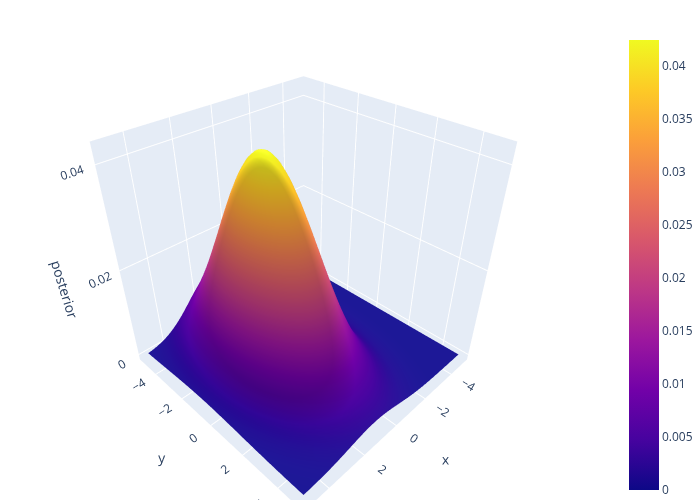

In [8]:
if __name__ == '__main__' and '__file__' not in globals():
  def make_pxy():
    def pxy(x, y):
      px = _gaussian(1.0, 1.5)
      py = _gaussian(-1.0, 2.5)
      return px(x) * py(y)
    return pxy
  pxy = make_pxy()
  _plot_surface(pxy)

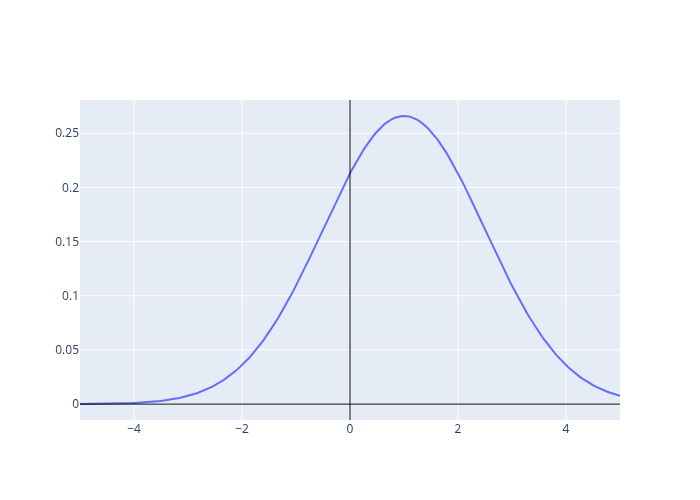

In [9]:
if __name__ == '__main__' and '__file__' not in globals():
  px = _marginalize(pxy=pxy, keep='x')
  _plot_function(px, (-5, 5))

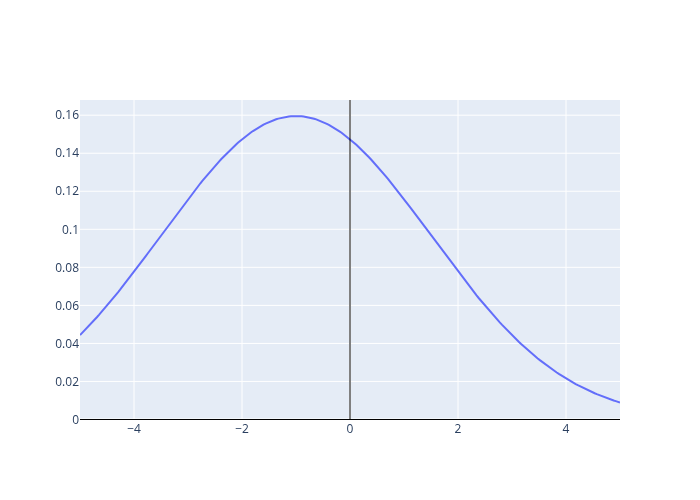

In [10]:
if __name__ == '__main__' and '__file__' not in globals():
  py = _marginalize(pxy=pxy, keep='y')
  _plot_function(py, (-5, 5))

<center>

**Testing/Playground Below** 

<small><em>
(always wrap with `if __name__ == '__main__' and '__file__' not in globals():`)
</em></small>

</center>

In [11]:
# explore: given an initial assumption of a location of something, and a reading on a noisy sensor about the location of that object, update the assumption of the location of the object

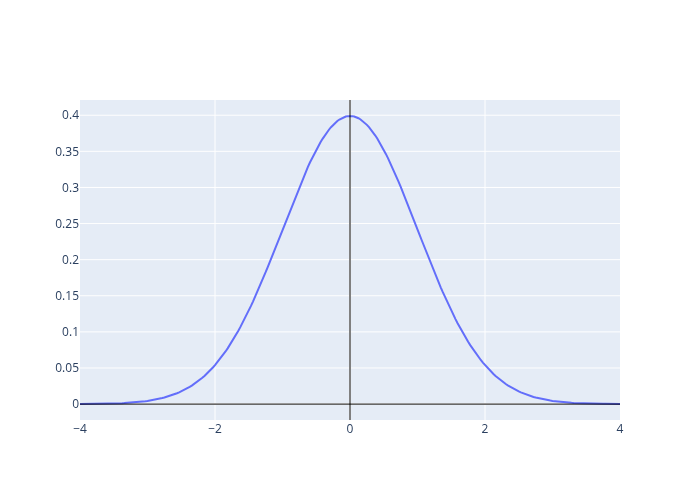

In [11]:
if __name__ == '__main__' and '__file__' not in globals():
  location = _gaussian(0.0, 1.0) #initial guess, 95% confidence that thing is between -2 and 2, with gaussian spread
  sensor = lambda y, x: _gaussian(x, 2.0)(y) #location sensor 95% confident in its reading within += 4 units
  reading = 2.0 #location sensor reads 2.0
  _plot_function(location, (-4, 4))

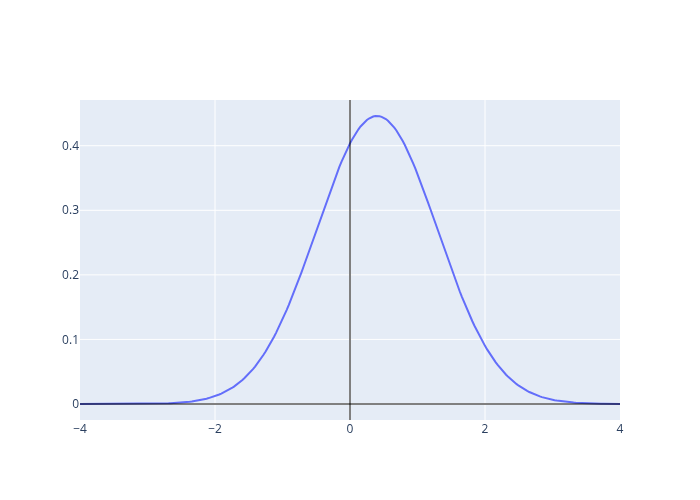

In [12]:
if __name__ == '__main__' and '__file__' not in globals():
  loc_given_sensor = _get_pxgy(pygx=sensor, px=location)
  loc = lambda x: loc_given_sensor(x, reading)
  _plot_function(loc, (-4, 4))

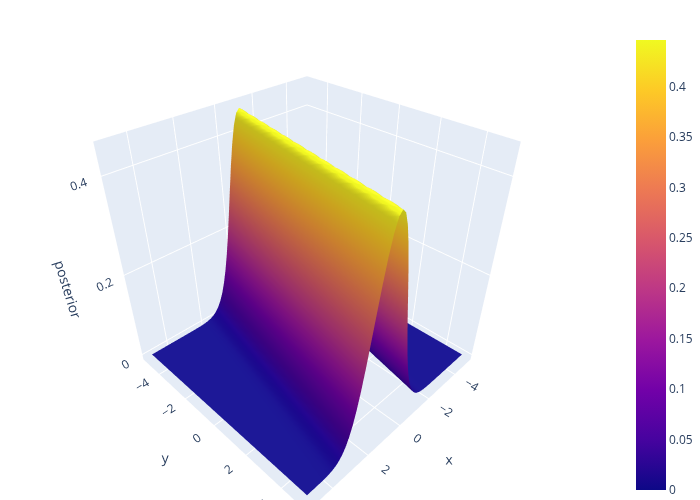

In [13]:
if __name__ == '__main__' and '__file__' not in globals():
  _plot_surface(loc_given_sensor)